<a href="https://colab.research.google.com/github/Alissa-Ouspen/data201_alissa/blob/main/week8/OUSPENSKAIA_Project1_Week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [122]:
import pandas as pd             # For handling data (DataFrame)
import seaborn as sns           # For visualizations and Planets dataset
import numpy as np              # For numerical operations
import matplotlib.pyplot as plt # For plots

from pandas import plotting

In [123]:
# Planets.csv is in the Seaborn library
# https://github.com/mwaskom/seaborn-data/blob/master/planets.csv
planets = sns.load_dataset("planets")
planets.head(50)
#type(planets)  # DataFrame

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.30,7.10,77.40,2006
1,Radial Velocity,1,874.77,2.21,56.95,2008
2,Radial Velocity,1,763.00,2.60,19.84,2011
3,Radial Velocity,1,326.03,19.40,110.62,2007
4,Radial Velocity,1,516.22,10.50,119.47,2009
5,Radial Velocity,1,185.84,4.80,76.39,2008
6,Radial Velocity,1,1773.40,4.64,18.15,2002
7,Radial Velocity,1,798.50,NaN,21.41,1996
8,Radial Velocity,1,993.30,10.30,73.10,2008
9,Radial Velocity,2,452.80,1.99,74.79,2010


In [124]:
# count the number of missing fields by field name

missing = planets.isna().sum()
missing_prop = round(missing / len(planets), 2)
print(missing_prop)
# type(missing)  # Series: need to convert to DataFrame

method           0.00
number           0.00
orbital_period   0.04
mass             0.50
distance         0.22
year             0.00
dtype: float64


In [125]:
missing_df = pd.DataFrame(      #  run only once per session
    {"Missing Count" : missing,
     "Missing Proportion" : missing_prop})

# missing_df = pd.DataFrame()   # alternative
#type(missing_df)  # make sure DataFrame
print(missing_df)



                Missing Count  Missing Proportion
method                      0                0.00
number                      0                0.00
orbital_period             43                0.04
mass                      522                0.50
distance                  227                0.22
year                        0                0.00


In [126]:
# add "Field" column for use as plot labels
missing_df["Field"] = missing_df.index
planet_field_df = pd.DataFrame(      #  run only once per session
    {"Field" : missing_df.index })
planet_field_df["Units"] = (
    "Technique used for discovery", "Num of planets in system", "Earth days",
    "Jupiter Units (M_jup)", "Parsecs (pc) to its star", "Discovery year")
print(planet_field_df)

#  https://deepwiki.com/mwaskom/seaborn-data/8.3-exoplanet-data
#  Distance = from earth or from host star?  in AU or in parsecs?

            Field                         Units
0          method  Technique used for discovery
1          number      Num of planets in system
2  orbital_period                    Earth days
3            mass         Jupiter Units (M_jup)
4        distance      Parsecs (pc) to its star
5            year                Discovery year


In [127]:
print("Descriptive Statistics:\n")
pd.options.display.float_format = '{:.2f}'.format
print(planets.describe())

#help(sns.load_dataset('planets'))

print("\n\n\"planets\" DataFrame summary and data types:\n")
print(planets.info())

Descriptive Statistics:

       number  orbital_period   mass  distance    year
count 1035.00          992.00 513.00    808.00 1035.00
mean     1.79         2002.92   2.64    264.07 2009.07
std      1.24        26014.73   3.82    733.12    3.97
min      1.00            0.09   0.00      1.35 1989.00
25%      1.00            5.44   0.23     32.56 2007.00
50%      1.00           39.98   1.26     55.25 2010.00
75%      2.00          526.00   3.04    178.50 2012.00
max      7.00       730000.00  25.00   8500.00 2014.00


"planets" DataFrame summary and data types:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   method          1035 non-null   object 
 1   number          1035 non-null   int64  
 2   orbital_period  992 non-null    float64
 3   mass            513 non-null    float64
 4   distance        808 non-null    float64
 5   year   

#Explanation of Units; References

###Distance:  
"Distance
The distance to the planet-hosting star, in parsecs (pc)."
NASA High Energy Astrophysics Science Archive Research Center (HEASARC)
EXOPLANETS - Extrasolar Planets Encyclopedia:  Parameters
https://heasarc.gsfc.nasa.gov/w3browse/all/exoplanets.html


AU  
The astronomical unit equal to 149,597,870,700 meters.  
Distance between Earth and the Sun = 1 AU.
https://www.bipm.org/documents/20126/41483022/SI-Brochure-9-EN.pdf  
The International System of Units (PDF), V3.01 (9th ed.),  
International Bureau of Weights and Measures, August 2024, p. 145, ISBN 978-92-822-2272-0

${AU} \approx 1.496 * 10^{11}{\text{ m}}$  

https://science.nasa.gov/exoplanets/discoveries-dashboard/  

####Parsec:
"The parsec (symbol: pc) is a unit of length used to measure the large distances to astronomical objects outside the Solar System, approximately equal to 3.26 light-years or 206265 astronomical units (au), i.e. 30.9 trillion kilometres (19.2 trillion miles)."

<br/>

###Mass:  
Jupiter Units
The Jupiter mass, also called Jovian mass, is the unit of mass equal to the total mass of the planet Jupiter.  
Jupiter mass is a common unit of mass in astronomy that is used to indicate the masses of other similarly-sized objects.  
${M_J} \approx 1.898 * 10^{27}{\text{ kg}}$  

https://ssd.jpl.nasa.gov/planets/phys_par.html  
NASA Jet Propulsion Laboratory, California Institute of Technology  
Solar System Dynamics Group page "Planetary Physical Parameters".  
Updated December 12, 2019.  Viewed March 29, 2026.  
Planet_Mass

From "EXOPLANETS - Extrasolar Planets Encyclopedia"  
Parameters:   
"The mass (or minimum mass) of the extrasolar planet, in Jupiter masses. For planets detected by radial velocity and timing, only the product M.sini, where i is the orbit inclination, is known in general. For transiting planets, i, hence M, is known from the fitting of the transit light curve. For planets detected by astrometry, i is directly inferred from the parent star orbit. For planets detected by radial velocity in multiplanet systems, it can sometimes be inferred from the dynamical analysis of the planet-planet interaction, and in a few years it will be inferred from direct imaging of some planets. Thus, when the inclination is known, rather than the value of M.sini i the true mass value M is given."
- NASA High Energy Astrophysics Science Archive Research Center (HEASARC)

https://heasarc.gsfc.nasa.gov/w3browse/all/exoplanets.html  
 last updated on 31 March 2026.


<br/>

###Example of usage:  
"TOI-5916 b is a gas giant exoplanet that orbits a M-type star.  
Its mass is 0.713 Jupiters, it takes 2.4 days to complete one orbit of its star, and is 0.0262 AU from its star."  
https://science.nasa.gov/exoplanet-catalog/toi-5916-b/
NASA "Eyes on Exoplanets" dashboard.  

<br/>


####Astronomical Units vs Lightyears:  
https://science.nasa.gov/solar-system/cosmic-distances/



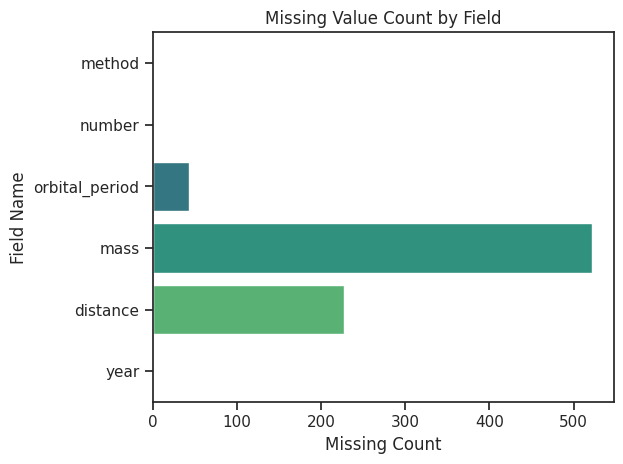

In [128]:
# Plot 1

sns.barplot(    # Horizontally-oriented bars
    data = missing_df, y = "Field", x = "Missing Count",
                hue = "Field", legend = False, palette = "viridis")
plt.title("Missing Value Count by Field")
plt.xlabel("Missing Count")
plt.ylabel("Field Name")
plt.tight_layout()
plt.show()

# sns.barplot(      # Vertically-oriented bars
#     data = missing_df, x = "Field", y = "Missing Count",
#             hue = "Field", legend = False, palette = "viridis")
# plt.xticks(rotation = 45, ha = "right")   # rotation = 90
# plt.xlabel("Field Name")
# plt.ylabel("Missing Count")

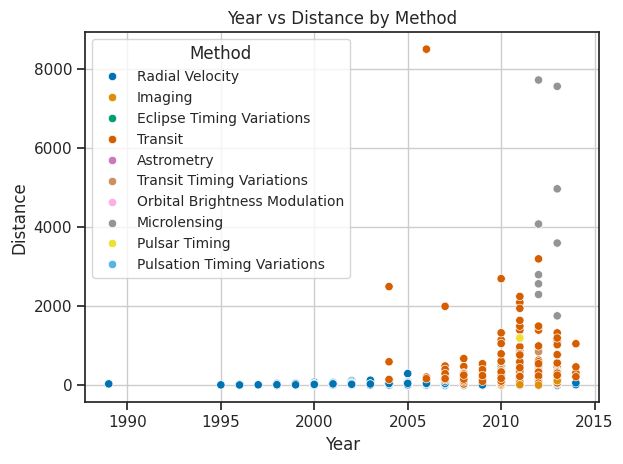

In [129]:
# Plot 2

sns.set_theme(style = "ticks", palette = "colorblind")
# ticks shows grid

#plt.figure(figsize = (10, 8)) # Increase figure size
sns.scatterplot(data = planets, x = "year", y = "distance", hue = "method")  # shows grid
plt.xlabel("Year")
plt.ylabel("Distance")
plt.title("Year vs Distance by Method")
plt.gca().legend_.set_title("Method")  # No need for this if legend is False
plt.grid()  #  need both ticks and grid
plt.legend(fontsize = "small", title = "Method")
    # , bbox_to_anchor = (0, -0.2), loc = "upper left") # Move legend outside
plt.tight_layout()
plt.show()

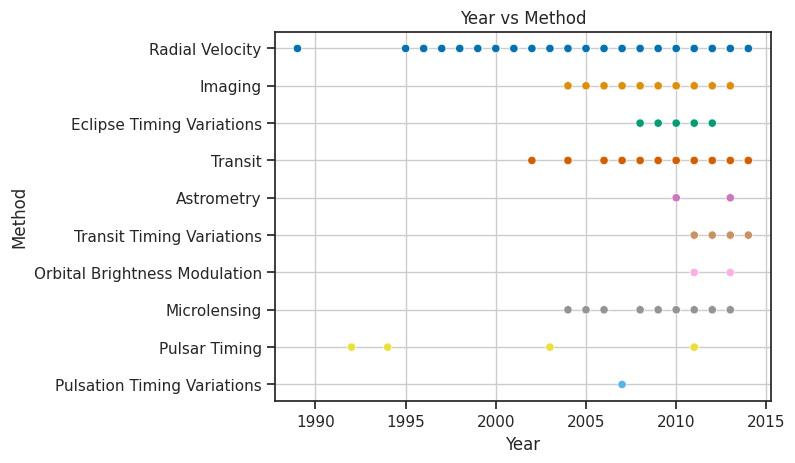

In [130]:
# Plot 3

sns.scatterplot(
    data = planets, x = "year", y = "method", hue = "method", legend = False)
plt.xlabel("Year")
plt.ylabel("Method")
plt.title("Year vs Method")
plt.grid()
plt.show()

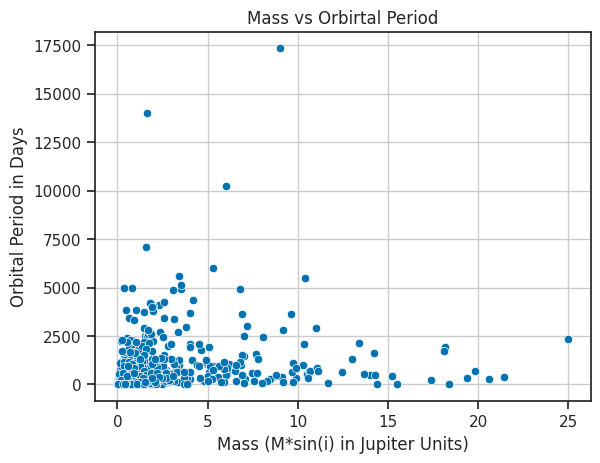

In [131]:
# Plot  4

sns.scatterplot(
    data = planets, x = "mass", y = "orbital_period")
plt.xlabel("Mass (M*sin(i) in Jupiter Units)")
plt.ylabel("Orbital Period in Days")
plt.title("Mass vs Orbirtal Period")
plt.grid()
plt.show()

In [132]:
#  the seaborn one looks better, is more legible
# pd.plotting.scatter_matrix(planets)
# plt.show()

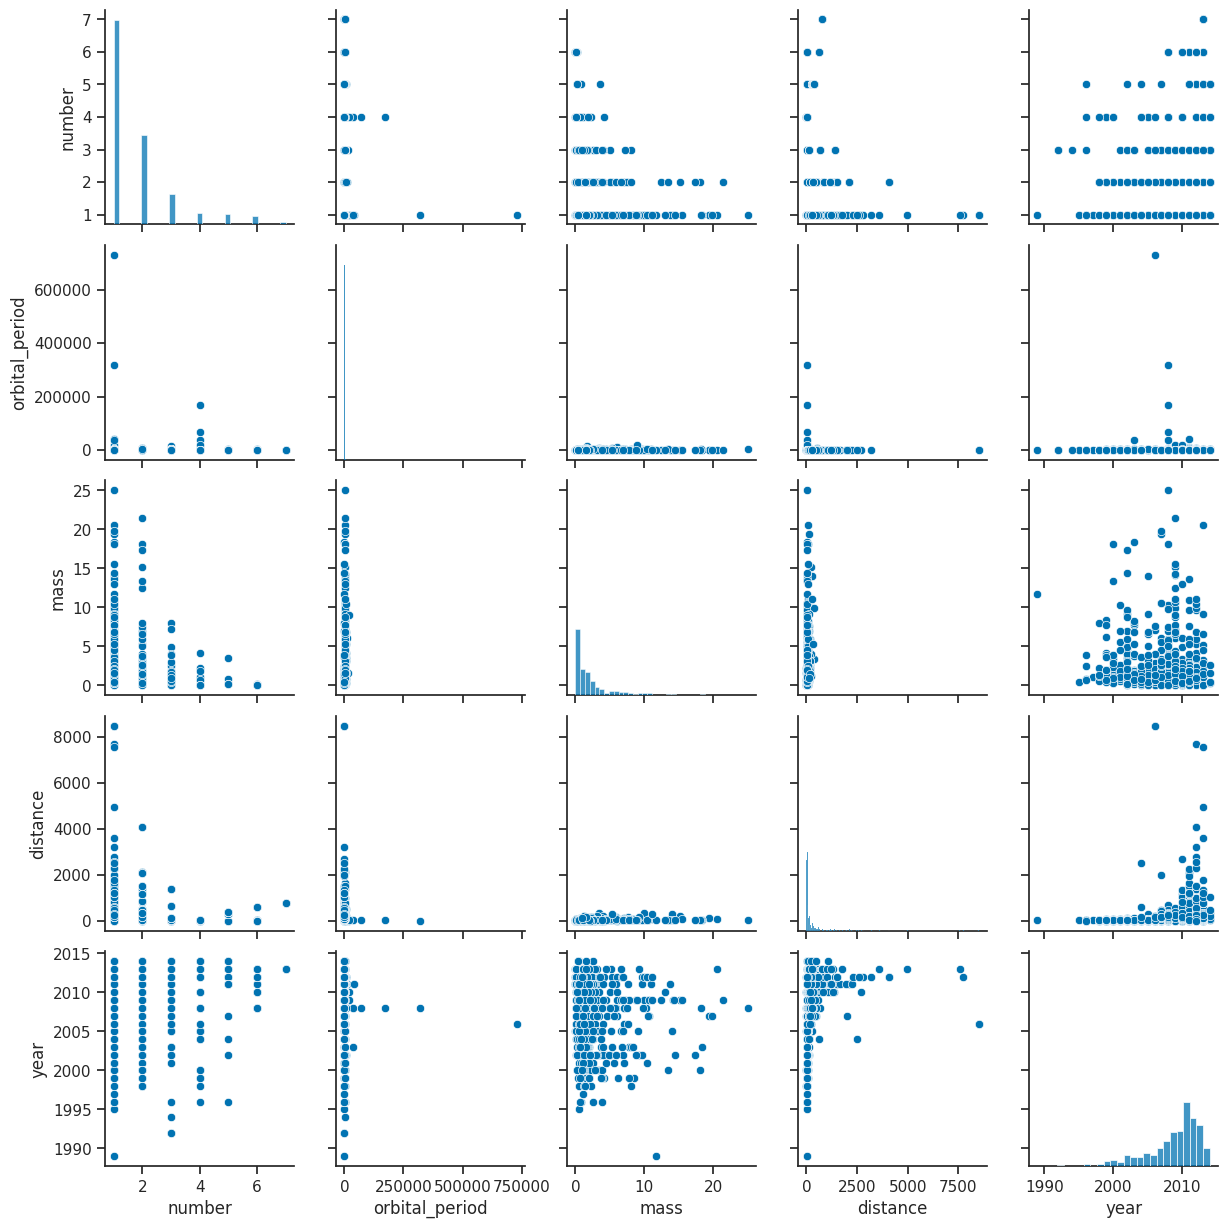

In [133]:
sns.pairplot(planets)
plt.show()

##Use of AI and reference material disclosure statement:  

Google Gemini was used to troubleshoot code, after several attempts to fix code failed.  
Independent attempts to fix code included making changes in response to error messages,  
reading documentation, and searching for suggestions online.  
Gemini was also used to get suggestions for customized formatting,  
after independent attempts were made. &nbsp;   
Many suggestions were rejected, and a lot were further customized independently.  
Each suggestion was evaluated against original code, to gain understanding about   
how and why particular statements do or do not work.  
AI was ***not*** used to avoid frustration or to significantly curtail the amount of time spent  
on the assignment.

Overall, AI was used to enrich practical experience and deepen understanding  
of the libraries and their attributes and how they interact with one another.    
It allowed more efficient exploration of how general code provided in course  
materials can be customized to fit particular situations and to dig deeper  
into questions about the data.    

Duck.ai was used to expedite Web searches, after conventional search attempts  
proved unreasonably time-consuming or unfruitful.  These included help with  
locating a list of datasets with 1,000 or more rows and explanations of the  
units used for mass and distance in the dataset.  
The most notably helpful search performed by Duck.ai was locating a reliable  
and authoritative source resolving the question of units used for distance:  
Seaborn documentation did not explain which units were used  
(lightyears/ Astronomical Units/ parsecs) and what they measured  
(distance from Earth or distance from the planet's hosting star).  
Various reference materials provided contradictory information.  
There remains some confusion about the relationship of the AU to the parsec,  
but the detailed explanation is outside the scope of the analysis of the  
dataset at this time.  

General searches on the Web were conducted conventionally to find examples of  
visualizations, when those attempted proved visually or structurally unsatisfactory.